In [47]:
# Project: Binary Classification using Logistic Regression
# Dataset: https://www.kaggle.com/datasets/abbas829/telco-customer-churn-dataset

In [48]:
# Phase 1
#Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [49]:
# Phase 1
# Load Dataset
df = pd.read_csv("/content/Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [50]:
# Phase 1
# First 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [51]:
# Phase 1
# Check dataset shape
print(df.shape)
# Dataset information
print(df.info())
# Statistical Summary
print(df.describe())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [52]:
# Phase 1
# Check Missing Values
print(df.isnull().sum())
# Check duplicate rows
print(df.duplicated().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
0


In [53]:
# Phase 1
# Numerical Columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

#Categorical Columns
cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')


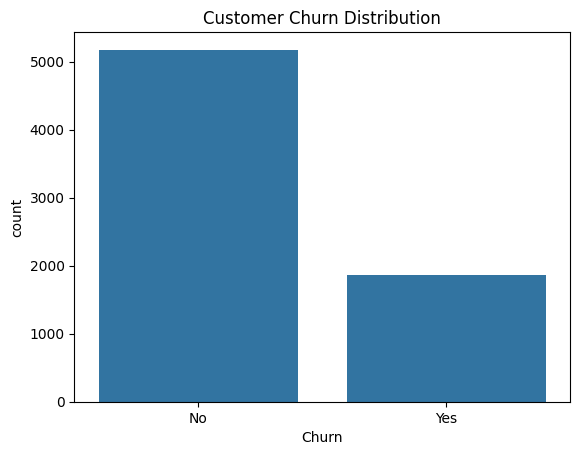

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [54]:
# Phase 1
# Count Plot for Target Variable
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Distribution")
plt.savefig("Target_Variable_Distribution.png")
plt.show()

# Percentage Distrubution
print(df['Churn'].value_counts(normalize=True)*100)

In [55]:
# The target variable distribution helps determine whether the dataset is balanced or imbalanced.
# As shown, the churn dataset is imbalanced.

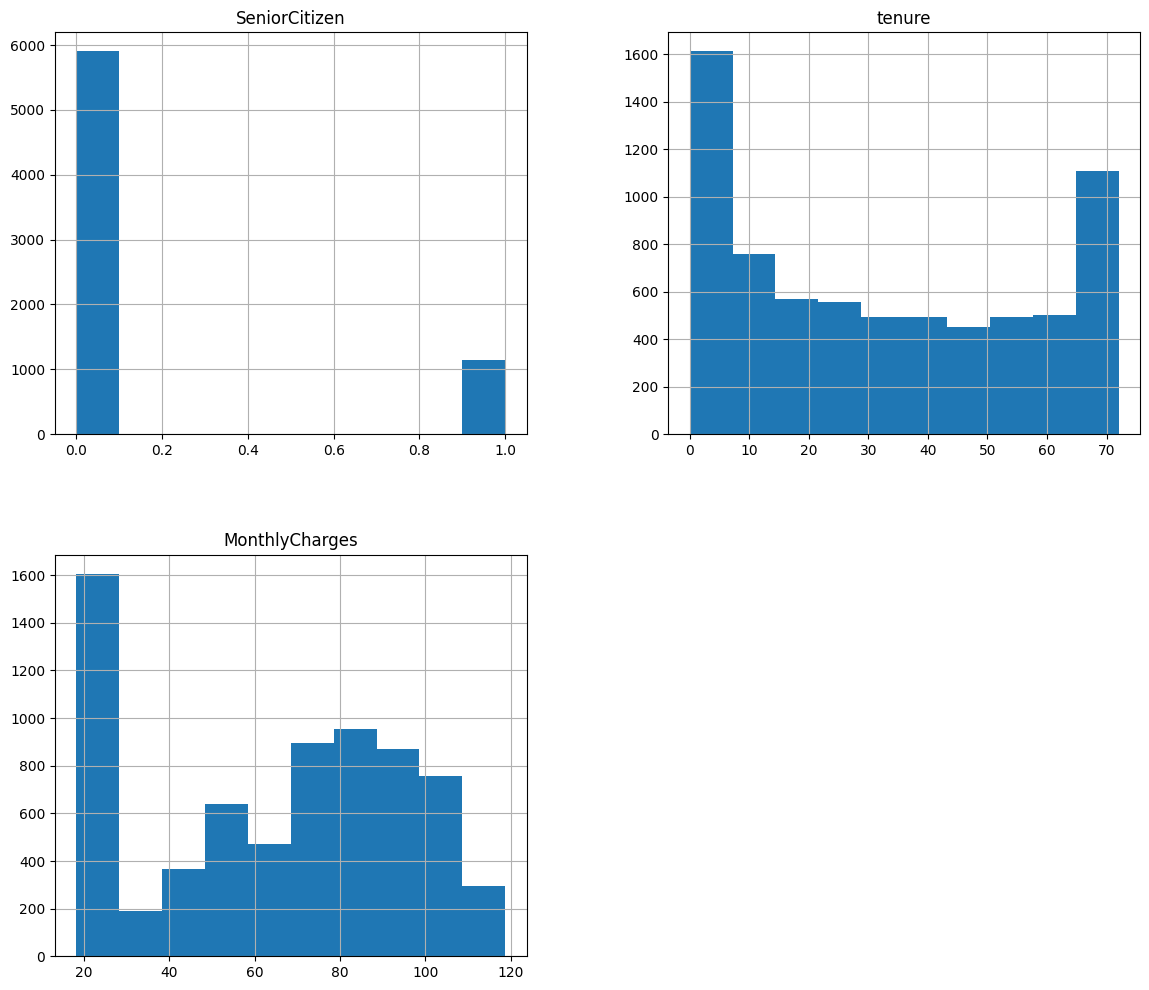

In [56]:
# Phase 1
# Histogram
df.hist(figsize=(14,12))
plt.savefig("Histogram_Distribution.png")
plt.show()

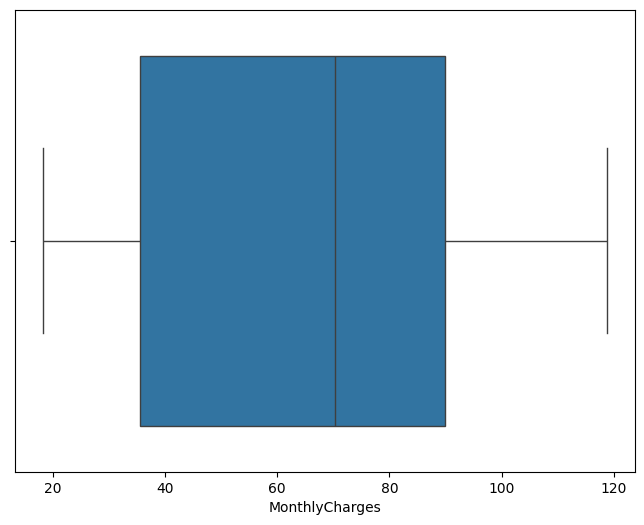

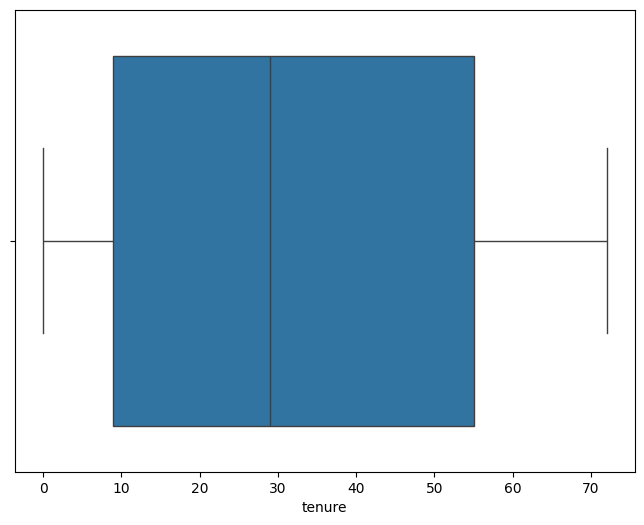

In [57]:
# Phase 1
# Boxplot for Monthly Charges
plt.figure(figsize=(8,6))
sns.boxplot(x=df['MonthlyCharges'])
plt.savefig("MonthlyCharges_Boxplot.png")
plt.show()
# Boxplot for Tenure
plt.figure(figsize=(8,6))
sns.boxplot(x=df['tenure'])
plt.savefig("Tenure_Boxplot.png")
plt.show()

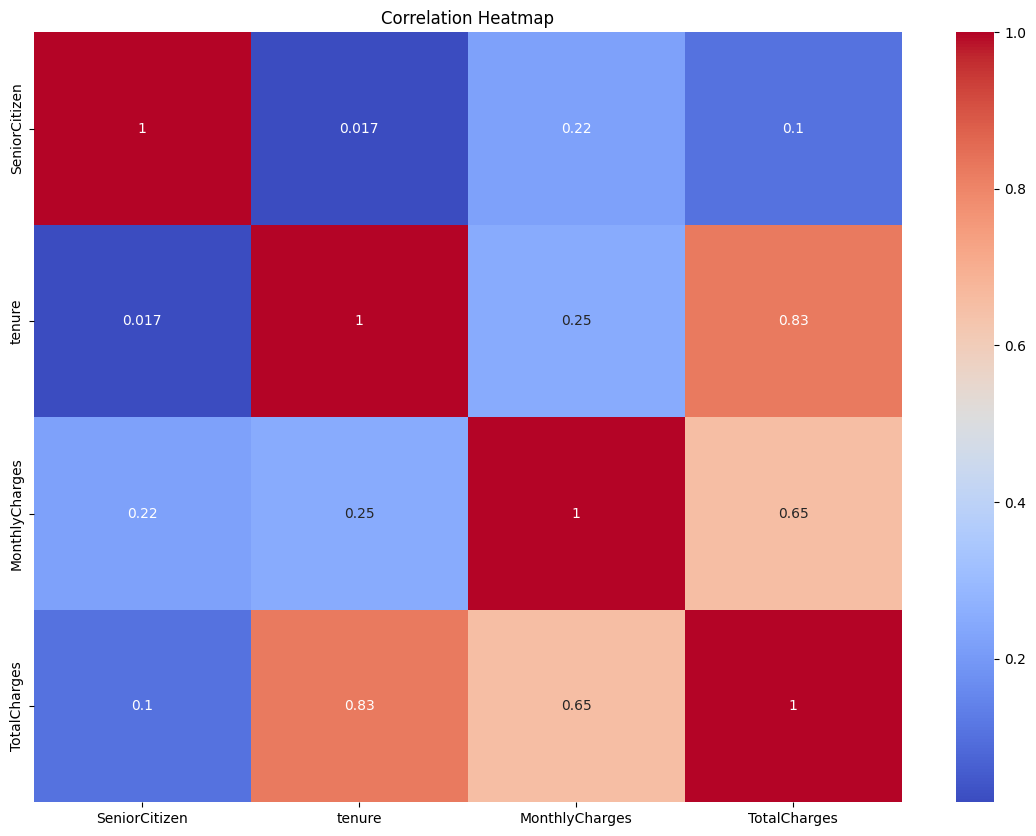

In [58]:
# Phase 1
# Correlation Heatmap

# Convert TotalCharges into numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Select numeric columns
numeric_df = df.select_dtypes(include=['number'])
# Correlation matrix
plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("Correlation_Heatmap.png")
plt.show()

In [59]:
# Phase 2
# Data Preprocessing
# Handle Missing Values
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [60]:
# Phase 2
# Check Missing Values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [61]:
# Phase 2
# Removing Unnecessary Columns
df.drop(['customerID'], axis=1, inplace=True)

In [62]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [63]:
# Phase 2
# Label Encoding
# Convert categorical variables into numerical form
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])
print(df.head())


   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   
1                 

In [64]:
# Phase 2
# Features and Target separation
x = df.drop('Churn', axis=1)
y = df['Churn']

In [65]:
# Phase 2
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [66]:
# Phase 2
# Train Test Split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x_scaled,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)

(5634, 19)
(1409, 19)


In [67]:
# Report statement:
#The dataset was divided into 80% training data and 20% testing data.

In [68]:
# Phase 3
# Logistic Regression Model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [69]:
# Hyperparameters Justification from above code:
# penalty='l2' - Controls overfitting.
# C=1.0 - Regularization strength.
# solver='lbfgs' - Efficient optimization algorithm.
# max_iter=1000 - Ensures convergence.

Accuracy: 0.8197303051809794
Confusion Matrix: [[936 100]
 [154 219]]
Precision: 0.6865203761755486
Recall: 0.5871313672922251
F1 Score: 0.6329479768786127
Classification Report:               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.59      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.81      1409



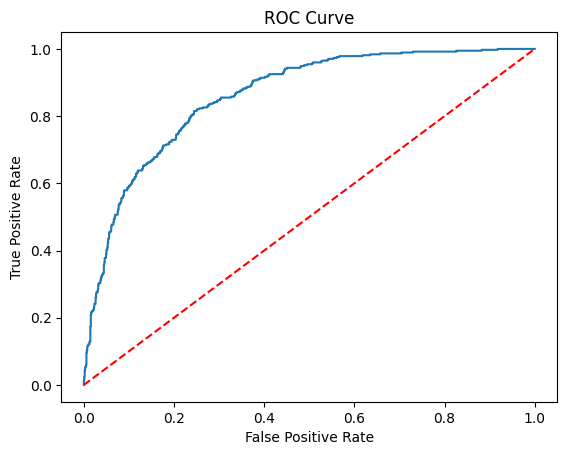

ROC AUC Score: 0.8596698479406253


In [70]:
# Phase 4
# Model Evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score

# Accuracy
A = accuracy_score(y_test, y_pred)
print("Accuracy:",A)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:",cm)

# Precison
P = precision_score(y_test, y_pred)
print("Precision:",P)

# Recall
R = recall_score(y_test, y_pred)
print("Recall:",R)

# F1 Score
F1 = f1_score(y_test, y_pred)
print("F1 Score:",F1)

# Classification Report
CR = classification_report(y_test, y_pred)
print("Classification Report:",CR)

# Roc Curve
y_prob = model.predict_proba(x_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.savefig("ROC Curve.png")
plt.show()

# Roc Auc Score
RAS = roc_auc_score(y_test, y_prob)
print("ROC AUC Score:", RAS)

In [71]:
# Phase 5
# Interpretation & Insights:
# Logistic Regression Coefficients
importance = pd.DataFrame({'Feature': x.columns, 'Coefficient': model.coef_[0]})
importance = importance.sort_values(by='Coefficient', ascending=False)
print(importance)

             Feature  Coefficient
17    MonthlyCharges     0.809093
7    InternetService     0.185626
15  PaperlessBilling     0.173392
6      MultipleLines     0.075970
16     PaymentMethod     0.073771
1      SeniorCitizen     0.067098
13   StreamingMovies     0.040599
2            Partner     0.032368
18      TotalCharges     0.000000
12       StreamingTV    -0.004855
0             gender    -0.026242
10  DeviceProtection    -0.062114
3         Dependents    -0.087370
9       OnlineBackup    -0.124211
11       TechSupport    -0.212005
8     OnlineSecurity    -0.244611
5       PhoneService    -0.295676
14          Contract    -0.599542
4             tenure    -0.804564


In [72]:
# Report for above analysis:
# Positive coefficients increase churn probability.
# Negative coefficients reduce churn probability.
# Features with larger absolute values have greater influence.

In [73]:
# Phase 6
# Conclusion Report:
# The Logistic Regression model successfully predicts customer churn using customer and service-related information.
# Data preprocessing, feature scaling, and proper evaluation improved model performance.
# Future Work:
# Apply 'SMOTE(Synthetic Minority Over-sampling Technique)' for class imbalance.
# Try Random Forest and XGBoost.
# Perform feature engineering.
# Use GridSearchCV for hyperparameter tuning.